In [1]:
import pandas as pd

# Load XRP CSV
xrp_df = pd.read_csv(r'feature_datasets\XRP_features.csv', parse_dates=True, index_col=0)

# Define X and y
xrp_y = xrp_df['Close'].shift(-1)          # next-day close price
xrp_X = xrp_df.drop(columns=['Close'])     # all other features

# Drop last row (y will be NaN)
xrp_X = xrp_X.iloc[:-1]
xrp_y = xrp_y.iloc[:-1]

# Optional: check shapes
print("XRP X shape:", xrp_X.shape)
print("XRP y shape:", xrp_y.shape)

XRP X shape: (915, 29)
XRP y shape: (915,)


## 70-30 split

In [2]:
# 70% train / 30% test split (time-based)
split_idx = int(len(xrp_X) * 0.7)

xrp_X_train = xrp_X.iloc[:split_idx].values
xrp_X_test  = xrp_X.iloc[split_idx:].values

xrp_y_train = xrp_y.iloc[:split_idx].values
xrp_y_test  = xrp_y.iloc[split_idx:].values

print("XRP X_train shape:", xrp_X_train.shape)
print("XRP X_test shape:", xrp_X_test.shape)
print("XRP y_train shape:", xrp_y_train.shape)
print("XRP y_test shape:", xrp_y_test.shape)

XRP X_train shape: (640, 29)
XRP X_test shape: (275, 29)
XRP y_train shape: (640,)
XRP y_test shape: (275,)


In [3]:
xrp_test_dates = xrp_df.index[-len(xrp_X_test):]

In [4]:
from sklearn.preprocessing import MinMaxScaler
import numpy as np

# Initialize scaler
scaler = MinMaxScaler()

# Fit on TRAIN only
xrp_X_train_scaled = scaler.fit_transform(xrp_X_train)

# Transform TEST using the same scaler
xrp_X_test_scaled = scaler.transform(xrp_X_test)

# Check shapes
print("Scaled X_train shape:", xrp_X_train_scaled.shape)
print("Scaled X_test shape:", xrp_X_test_scaled.shape)

Scaled X_train shape: (640, 29)
Scaled X_test shape: (275, 29)


In [5]:
# Initialize scaler for y
y_scaler = MinMaxScaler()

# Scale training target
xrp_y_train_scaled = y_scaler.fit_transform(xrp_y_train.reshape(-1,1)).flatten()

# Scale test target
xrp_y_test_scaled = y_scaler.transform(xrp_y_test.reshape(-1,1)).flatten()

In [6]:
def create_sequences(X, y, time_steps=30):
    X_seq, y_seq = [], []
    for i in range(len(X) - time_steps):
        X_seq.append(X[i:i+time_steps])
        y_seq.append(y[i+time_steps])  # the next day after the sequence
    return np.array(X_seq), np.array(y_seq)

# Create sequences for XRP using scaled target
xrp_X_train_seq, xrp_y_train_seq = create_sequences(xrp_X_train_scaled, xrp_y_train_scaled, time_steps=30)
xrp_X_test_seq, xrp_y_test_seq = create_sequences(xrp_X_test_scaled, xrp_y_test_scaled, time_steps=30)

# Check shapes
print("XRP X_train_seq shape:", xrp_X_train_seq.shape)
print("XRP y_train_seq shape:", xrp_y_train_seq.shape)
print("XRP X_test_seq shape:", xrp_X_test_seq.shape)
print("XRP y_test_seq shape:", xrp_y_test_seq.shape)

XRP X_train_seq shape: (610, 30, 29)
XRP y_train_seq shape: (610,)
XRP X_test_seq shape: (245, 30, 29)
XRP y_test_seq shape: (245,)


### Model training

In [7]:
from Bi_LSTM import BiLSTM, train_model, predict_model

In [8]:
# Get number of features from the sequences
input_size = xrp_X_train_seq.shape[2]

# Initialize Bi-LSTM model
model = BiLSTM(input_size=input_size)

In [9]:
model = train_model(model, xrp_X_train_seq, xrp_y_train_seq, epochs=50, batch_size=32, lr=0.001)

Epoch [10/50], Loss: 0.003640
Epoch [20/50], Loss: 0.004584
Epoch [30/50], Loss: 0.002680
Epoch [40/50], Loss: 0.002954
Epoch [50/50], Loss: 0.001206


In [10]:
xrp_preds = predict_model(model, xrp_X_test_seq)

# check
print("Predictions shape:", xrp_preds.shape)
print("First 10 predictions:", xrp_preds[:10])

Predictions shape: (245, 1)
First 10 predictions: [[0.14466071]
 [0.13704416]
 [0.12898776]
 [0.12213854]
 [0.1154894 ]
 [0.1146226 ]
 [0.11073322]
 [0.10370857]
 [0.09909841]
 [0.08789676]]


In [11]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

# Inverse scale predictions
xrp_preds_actual = y_scaler.inverse_transform(xrp_preds.reshape(-1,1))

# Skip first 30 because of 30-day sequence
xrp_y_test_actual = xrp_y_test[30:].reshape(-1,1)

# Calculate metrics
mse = mean_squared_error(xrp_y_test_actual, xrp_preds_actual)
rmse = np.sqrt(mse)
mae = mean_absolute_error(xrp_y_test_actual, xrp_preds_actual)
r2 = r2_score(xrp_y_test_actual, xrp_preds_actual)

print(f"MSE: {mse:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"MAE: {mae:.2f}")
print(f"R2 Score: {r2:.4f}")

MSE: 0.00
RMSE: 0.05
MAE: 0.04
R2 Score: 0.6085


In [12]:
xrp_preds_actual = y_scaler.inverse_transform(xrp_preds.reshape(-1,1))

In [14]:
import pandas as pd
import matplotlib.pyplot as plt

# Skip first 30 because of sequence
dates_seq = xrp_df.index[-len(xrp_X_test):][30:]  # test dates aligned with sequences
actual_seq = xrp_y_test[30:]                      # actual prices aligned
pred_seq = xrp_preds_actual                       # predicted prices aligned

# Create DataFrame
df_plot = pd.DataFrame({
    "Date": dates_seq,
    "Actual": actual_seq,
    "Predicted": pred_seq.flatten()
})

df_plot.set_index("Date", inplace=True)
df_plot

,Actual,Predicted
Date,,
2023-05-02,0.464951,0.464515
2023-05-03,0.463494,0.456279
2023-05-04,0.461573,0.447567
2023-05-05,0.467800,0.440161
2023-05-06,0.459549,0.432971
...,...,...
2023-12-28,0.634998,0.537956
2023-12-29,0.623402,0.541120
2023-12-30,0.621844,0.544409


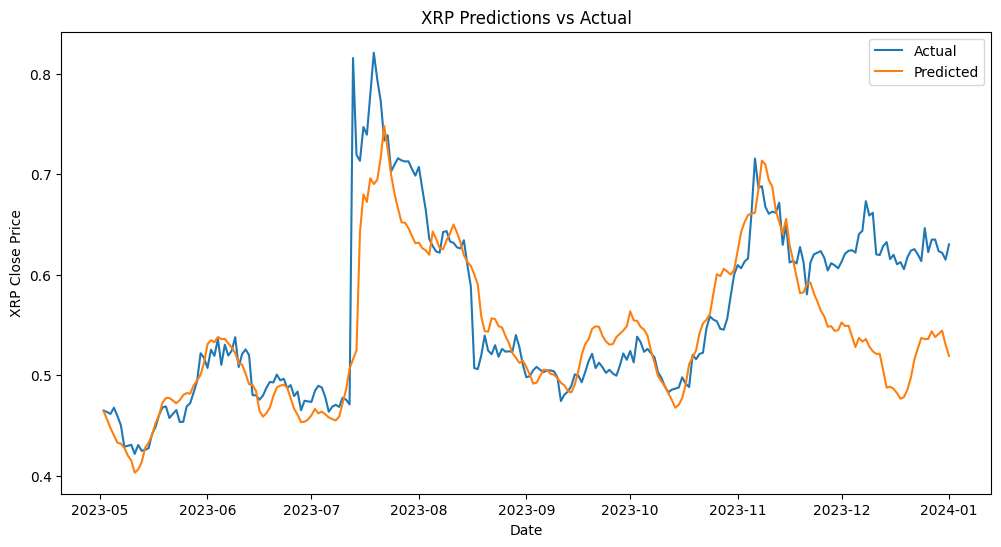

In [15]:
plt.figure(figsize=(12,6))
plt.plot(df_plot["Actual"], label="Actual")
plt.plot(df_plot["Predicted"], label="Predicted")
plt.xlabel("Date")
plt.ylabel("XRP Close Price")
plt.title("XRP Predictions vs Actual")
plt.legend()
plt.show()